# 🧠 MSA — Implémentation complète de Memory Sparse Attention

> **Implémentation from scratch en NumPy** de l'architecture MSA
> *(Chen et al., "Memory Sparse Attention for Efficient End-to-End Memory Model Scaling to 100M Tokens")*

Ce notebook implémente chaque composant de MSA, l'assemble en un pipeline complet,
puis le teste sur des tâches de retrieval synthétiques.

### Architecture implémentée

```
Corpus (N docs) ──→ [Document Encoder] ──→ KV Cache compressé (K̄, V̄, K̄ᴿ)
                                                    │
Query ──→ [Router Q Projector] ──→ Q^R ──→ [Top-k Routing] ──→ Docs sélectionnés
                                                    │
                    [Sparse Attention sur contexte réduit] ──→ Réponse
```

### Sommaire

1. Briques de base (RoPE, Multi-Head Attention, RMSNorm)
2. Router Projectors (Q^R, K^R)
3. KV Cache Compression (Mean Pooling)
4. Document-wise RoPE
5. Mécanisme de routage Top-k
6. Couche MSA complète
7. Pipeline d'inférence 3 stages
8. Memory Interleave (multi-hop)
9. Démo end-to-end sur données synthétiques
10. Benchmarks de performance


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import time
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
import warnings
warnings.filterwarnings('ignore')

# ---------- Configuration globale ----------
@dataclass
class MSAConfig:
    """Configuration de l'architecture MSA."""
    d_model: int = 256          # Dimension du modèle
    n_heads: int = 8            # Nombre de têtes d'attention
    d_head: int = 32            # Dimension par tête (d_model / n_heads)
    n_layers: int = 6           # Nombre de couches totales
    n_msa_layers: int = 3       # Couches MSA (moitié haute)
    d_ffn: int = 512            # Dimension FFN
    chunk_size: int = 16        # Taille de chunk pour le pooling (P)
    top_k: int = 8              # Nombre de documents top-k
    rope_base: float = 10000.0  # Base pour RoPE
    rope_theta_scale: float = 1.0
    vocab_size: int = 1000      # Taille vocabulaire (simplifiée)

config = MSAConfig()

# Style matplotlib
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'text.color': '#c9d1d9', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
    'font.size': 10, 'axes.titleweight': 'bold'
})
C = {'blue': '#58a6ff', 'green': '#7ee787', 'orange': '#ffa657',
     'red': '#f97583', 'purple': '#d2a8ff', 'yellow': '#ffd700', 'gray': '#8b949e'}

np.random.seed(42)
print(f"✅ Config MSA initialisée:")
print(f"   d_model={config.d_model}, n_heads={config.n_heads}, "
      f"chunk_size={config.chunk_size}, top_k={config.top_k}")
print(f"   {config.n_layers} couches dont {config.n_msa_layers} couches MSA (moitié haute)")


✅ Config MSA initialisée:
   d_model=256, n_heads=8, chunk_size=16, top_k=8
   6 couches dont 3 couches MSA (moitié haute)


---
## 1. 🧱 Briques de base

### 1.1 RMSNorm

Normalisation utilisée dans les architectures modernes (Qwen, LLaMA).


In [2]:
class RMSNorm:
    """Root Mean Square Layer Normalization."""

    def __init__(self, d_model: int, eps: float = 1e-6):
        self.weight = np.ones(d_model)
        self.eps = eps

    def __call__(self, x: np.ndarray) -> np.ndarray:
        rms = np.sqrt(np.mean(x ** 2, axis=-1, keepdims=True) + self.eps)
        return (x / rms) * self.weight

# Test
norm = RMSNorm(config.d_model)
test_x = np.random.randn(2, 10, config.d_model)
out = norm(test_x)
print(f"RMSNorm: entrée {test_x.shape} → sortie {out.shape}")
print(f"  RMS avant: {np.sqrt(np.mean(test_x**2, axis=-1)).mean():.4f}")
print(f"  RMS après: {np.sqrt(np.mean(out**2, axis=-1)).mean():.4f} (≈1.0)")


RMSNorm: entrée (2, 10, 256) → sortie (2, 10, 256)
  RMS avant: 0.9958
  RMS après: 1.0000 (≈1.0)


### 1.2 Rotary Position Embedding (RoPE)

L'encodage positionnel rotatif encode les positions via des rotations dans l'espace des paires de dimensions.

$$\text{RoPE}(x_m, m) = \begin{pmatrix} x_{m,0} \cos(m\theta_0) - x_{m,1} \sin(m\theta_0) \\ x_{m,0} \sin(m\theta_0) + x_{m,1} \cos(m\theta_0) \\ \vdots \end{pmatrix}$$

où $\theta_i = \text{base}^{-2i/d}$.


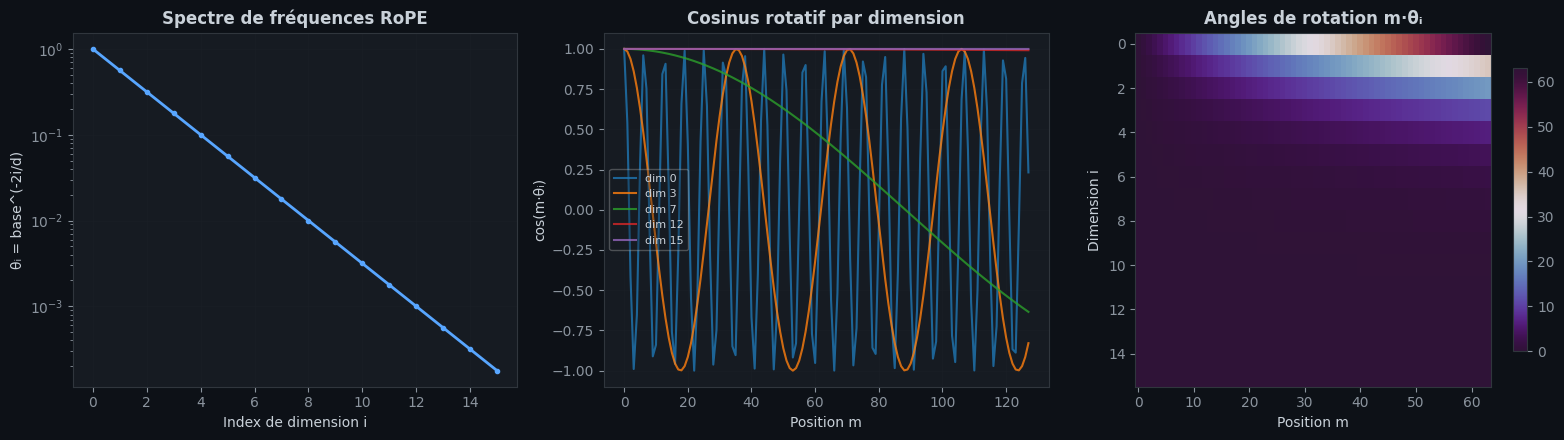

✅ dot(RoPE(q,50), RoPE(k,45)) = -0.7507
   dot(RoPE(q,30), RoPE(k,25)) = -0.7507
   → Même écart relatif (5) = même score ✓


In [3]:
class RotaryPositionEmbedding:
    """
    RoPE — Rotary Position Embedding.
    Encode les positions via des rotations 2D dans l'espace des features.
    """

    def __init__(self, d_head: int, base: float = 10000.0):
        self.d_head = d_head
        self.base = base
        # Fréquences θ_i = base^(-2i/d) pour i = 0, 1, ..., d/2-1
        i = np.arange(0, d_head, 2, dtype=np.float64)
        self.freqs = 1.0 / (base ** (i / d_head))

    def _build_rotation(self, positions: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Construit cos(m·θ) et sin(m·θ) pour chaque position m.

        Args:
            positions: [seq_len] array d'indices de position
        Returns:
            cos_cache, sin_cache: [seq_len, d_head/2]
        """
        # positions: [seq_len], freqs: [d_head/2]
        # outer product → [seq_len, d_head/2]
        angles = np.outer(positions.astype(np.float64), self.freqs)
        return np.cos(angles).astype(np.float32), np.sin(angles).astype(np.float32)

    def apply(self, x: np.ndarray, positions: np.ndarray) -> np.ndarray:
        """
        Applique RoPE aux vecteurs x.

        Args:
            x: [..., seq_len, d_head] — Q ou K
            positions: [seq_len] — indices de position
        Returns:
            x_rotated: même shape que x
        """
        seq_len = x.shape[-2]
        cos_m, sin_m = self._build_rotation(positions)  # [seq_len, d_head/2]

        # Reshape pour broadcast: [1, ..., seq_len, d_head/2]
        while cos_m.ndim < x.ndim:
            cos_m = cos_m[np.newaxis]
            sin_m = sin_m[np.newaxis]

        # Séparer les paires de dimensions
        x1 = x[..., 0::2]  # dims paires
        x2 = x[..., 1::2]  # dims impaires

        # Rotation 2D par paire
        x_rot = np.empty_like(x)
        x_rot[..., 0::2] = x1 * cos_m - x2 * sin_m
        x_rot[..., 1::2] = x1 * sin_m + x2 * cos_m

        return x_rot

# ---- Démonstration visuelle ----
rope = RotaryPositionEmbedding(config.d_head)

# Visualiser les patterns de rotation pour différentes positions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Fréquences θ
ax = axes[0]
dims = np.arange(len(rope.freqs))
ax.semilogy(dims, rope.freqs, color=C['blue'], lw=2, marker='o', markersize=3)
ax.set_xlabel('Index de dimension i')
ax.set_ylabel('θᵢ = base^(-2i/d)')
ax.set_title('Spectre de fréquences RoPE')
ax.grid(True, alpha=0.2)

# Plot 2: cos(m·θ) pour quelques dimensions
ax = axes[1]
positions = np.arange(128)
cos_cache, sin_cache = rope._build_rotation(positions)
for dim_idx in [0, 3, 7, 12, 15]:
    ax.plot(positions, cos_cache[:, dim_idx], lw=1.5,
            label=f'dim {dim_idx}', alpha=0.8)
ax.set_xlabel('Position m')
ax.set_ylabel('cos(m·θᵢ)')
ax.set_title('Cosinus rotatif par dimension')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True, alpha=0.2)

# Plot 3: Heatmap angles
ax = axes[2]
angles = np.outer(positions[:64], rope.freqs)
im = ax.imshow(angles.T, aspect='auto', cmap='twilight_shifted')
ax.set_xlabel('Position m')
ax.set_ylabel('Dimension i')
ax.set_title('Angles de rotation m·θᵢ')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# Vérifier la propriété clé : dot(RoPE(q,m), RoPE(k,n)) ne dépend que de m-n
q = np.random.randn(1, 1, config.d_head)
k = np.random.randn(1, 1, config.d_head)

dots = []
for offset in range(20):
    q_rot = rope.apply(q, np.array([50]))
    k_rot = rope.apply(k, np.array([50 - offset]))
    dots.append(np.sum(q_rot * k_rot))

q_rot0 = rope.apply(q, np.array([30]))
k_rot0 = rope.apply(k, np.array([30 - 5]))
dot_check = np.sum(q_rot0 * k_rot0)
print(f"✅ dot(RoPE(q,50), RoPE(k,45)) = {dots[5]:.4f}")
print(f"   dot(RoPE(q,30), RoPE(k,25)) = {dot_check:.4f}")
print(f"   → Même écart relatif (5) = même score ✓")


### 1.3 Multi-Head Attention (avec RoPE)

In [4]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    """Softmax numériquement stable."""
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)


class MultiHeadAttention:
    """
    Multi-Head Attention avec RoPE.

    Paramètres apprenables :
        W_Q, W_K, W_V : [d_model, n_heads * d_head]
        W_O            : [n_heads * d_head, d_model]
    """

    def __init__(self, config: MSAConfig):
        self.n_heads = config.n_heads
        self.d_head = config.d_head
        self.d_model = config.d_model
        scale = 1.0 / np.sqrt(config.d_model)

        # Projections (initialisées Xavier)
        self.W_Q = np.random.randn(config.d_model, config.n_heads * config.d_head).astype(np.float32) * scale
        self.W_K = np.random.randn(config.d_model, config.n_heads * config.d_head).astype(np.float32) * scale
        self.W_V = np.random.randn(config.d_model, config.n_heads * config.d_head).astype(np.float32) * scale
        self.W_O = np.random.randn(config.n_heads * config.d_head, config.d_model).astype(np.float32) * scale

        self.rope = RotaryPositionEmbedding(config.d_head, config.rope_base)

    def project_qkv(self, x: np.ndarray):
        """
        Projette x en Q, K, V multi-têtes.

        Args:
            x: [batch, seq_len, d_model]
        Returns:
            Q, K, V: [batch, n_heads, seq_len, d_head]
        """
        B, S, D = x.shape
        Q = (x @ self.W_Q).reshape(B, S, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        K = (x @ self.W_K).reshape(B, S, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        V = (x @ self.W_V).reshape(B, S, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        return Q, K, V

    def attention(self, Q: np.ndarray, K: np.ndarray, V: np.ndarray,
                  q_positions: np.ndarray, k_positions: np.ndarray,
                  mask: Optional[np.ndarray] = None) -> np.ndarray:
        """
        Attention avec RoPE appliqué à Q et K.

        Args:
            Q: [batch, n_heads, q_len, d_head]
            K: [batch, n_heads, k_len, d_head]
            V: [batch, n_heads, k_len, d_head]
            q_positions: [q_len]
            k_positions: [k_len]
            mask: optionnel [q_len, k_len]
        Returns:
            output: [batch, n_heads, q_len, d_head]
            attn_weights: [batch, n_heads, q_len, k_len]
        """
        # Appliquer RoPE
        Q_rot = self.rope.apply(Q, q_positions)
        K_rot = self.rope.apply(K, k_positions)

        # Scaled dot-product attention
        scale = 1.0 / np.sqrt(self.d_head)
        scores = np.einsum('bhqd,bhkd->bhqk', Q_rot, K_rot) * scale

        if mask is not None:
            scores = scores + mask[np.newaxis, np.newaxis, :, :]

        weights = softmax(scores, axis=-1)
        output = np.einsum('bhqk,bhkd->bhqd', weights, V)

        return output, weights

    def forward(self, x: np.ndarray, positions: np.ndarray,
                kv_cache: Optional[Tuple] = None,
                k_positions: Optional[np.ndarray] = None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Forward pass complet.

        Args:
            x: [batch, seq_len, d_model]
            positions: [seq_len] indices de position pour Q
            kv_cache: optionnel (K_ext, V_ext, k_ext_positions) à prepend
        Returns:
            output: [batch, seq_len, d_model]
            attn_weights
        """
        Q, K, V = self.project_qkv(x)
        q_pos = positions

        if kv_cache is not None:
            K_ext, V_ext, kv_ext_pos = kv_cache
            K = np.concatenate([K_ext, K], axis=2)
            V = np.concatenate([V_ext, V], axis=2)
            k_pos = np.concatenate([kv_ext_pos, positions])
        else:
            k_pos = positions if k_positions is None else k_positions

        output, weights = self.attention(Q, K, V, q_pos, k_pos)

        # Reshape et projection de sortie
        B, _, S, _ = output.shape
        output = output.transpose(0, 2, 1, 3).reshape(B, S, -1)
        output = output @ self.W_O

        return output, weights


# Test
mha = MultiHeadAttention(config)
x_test = np.random.randn(1, 20, config.d_model).astype(np.float32)
pos_test = np.arange(20)
out_test, w_test = mha.forward(x_test, pos_test)
print(f"Multi-Head Attention:")
print(f"  Entrée:  {x_test.shape}")
print(f"  Sortie:  {out_test.shape}")
print(f"  Poids:   {w_test.shape} (batch, heads, q_len, k_len)")
print(f"  Somme poids par ligne: {w_test[0, 0, 0].sum():.4f} (≈1.0)")


Multi-Head Attention:
  Entrée:  (1, 20, 256)
  Sortie:  (1, 20, 256)
  Poids:   (1, 8, 20, 20) (batch, heads, q_len, k_len)
  Somme poids par ligne: 1.0000 (≈1.0)


---
## 2. 🎯 Router Projectors

MSA introduit des **projections de routage spécialisées** (W_QR, W_KR), séparées des projections d'attention standard.

Le routage opère dans un espace dédié pour identifier les documents pertinents,
tandis que K et V standard sont utilisés pour l'attention proprement dite.


In [5]:
class RouterProjector:
    """
    Router Projectors pour le mécanisme de sélection Top-k.

    Projections séparées :
    - W_KR : projette les hidden states des documents → clés de routage
    - W_QR : projette les hidden states de la query → vecteurs de routage

    Ces projections sont DISTINCTES de W_K et W_Q de l'attention,
    permettant au routage d'apprendre un espace de pertinence optimisé
    indépendamment de l'espace d'attention.
    """

    def __init__(self, config: MSAConfig):
        self.n_heads = config.n_heads
        self.d_head = config.d_head
        scale = 1.0 / np.sqrt(config.d_model)

        # Router Key Projector : documents → routing keys
        self.W_KR = np.random.randn(
            config.d_model, config.n_heads * config.d_head
        ).astype(np.float32) * scale

        # Router Query Projector : query → routing queries
        self.W_QR = np.random.randn(
            config.d_model, config.n_heads * config.d_head
        ).astype(np.float32) * scale

    def project_key(self, H_doc: np.ndarray) -> np.ndarray:
        """
        Projette les hidden states d'un document en clés de routage.

        Args:
            H_doc: [batch, seq_len, d_model]
        Returns:
            KR: [batch, n_heads, seq_len, d_head]
        """
        B, S, D = H_doc.shape
        KR = (H_doc @ self.W_KR).reshape(B, S, self.n_heads, self.d_head)
        return KR.transpose(0, 2, 1, 3)

    def project_query(self, H_query: np.ndarray) -> np.ndarray:
        """
        Projette les hidden states de la query en vecteurs de routage.

        Args:
            H_query: [batch, seq_len, d_model]
        Returns:
            QR: [batch, n_heads, seq_len, d_head]
        """
        B, S, D = H_query.shape
        QR = (H_query @ self.W_QR).reshape(B, S, self.n_heads, self.d_head)
        return QR.transpose(0, 2, 1, 3)


# ---- Démonstration ----
router = RouterProjector(config)

# Simuler un document et une query
H_doc = np.random.randn(1, 64, config.d_model).astype(np.float32)
H_query = np.random.randn(1, 16, config.d_model).astype(np.float32)

KR = router.project_key(H_doc)
QR = router.project_query(H_query)

print("Router Projectors:")
print(f"  Document hidden states: {H_doc.shape}")
print(f"  → Routing Keys K^R:     {KR.shape}  (batch, heads, doc_len, d_head)")
print(f"  Query hidden states:    {H_query.shape}")
print(f"  → Routing Queries Q^R:  {QR.shape}  (batch, heads, q_len, d_head)")
print(f"\n  ⚠️  K^R et Q^R vivent dans un espace SÉPARÉ de K et Q de l'attention")
print(f"      → Le routage peut optimiser la pertinence indépendamment du contenu")


Router Projectors:
  Document hidden states: (1, 64, 256)
  → Routing Keys K^R:     (1, 8, 64, 32)  (batch, heads, doc_len, d_head)
  Query hidden states:    (1, 16, 256)
  → Routing Queries Q^R:  (1, 8, 16, 32)  (batch, heads, q_len, d_head)

  ⚠️  K^R et Q^R vivent dans un espace SÉPARÉ de K et Q de l'attention
      → Le routage peut optimiser la pertinence indépendamment du contenu


---
## 3. 📦 KV Cache Compression par Mean Pooling

Chaque document est découpé en **chunks de taille P** (=16 ici, 64 dans le papier).
On comprime chaque chunk par mean pooling pour réduire l'empreinte mémoire d'un facteur P.

$$\bar{K}_{i} = \phi(K_i) = \text{MeanPool}_{P}(K_i)$$


Compression KV Cache (P=16):
  K original:    (1, 8, 256, 32)  (256.0 KB)
  K̄ compressé:   (1, 8, 16, 32)  (16.0 KB)
  Ratio:          ×16 de réduction

  Pour 100M tokens avec 8 heads, 32d, 18 layers en BF16:
  Sans compression: 2575 GB
  Avec compression: 160.9 GB (÷16)


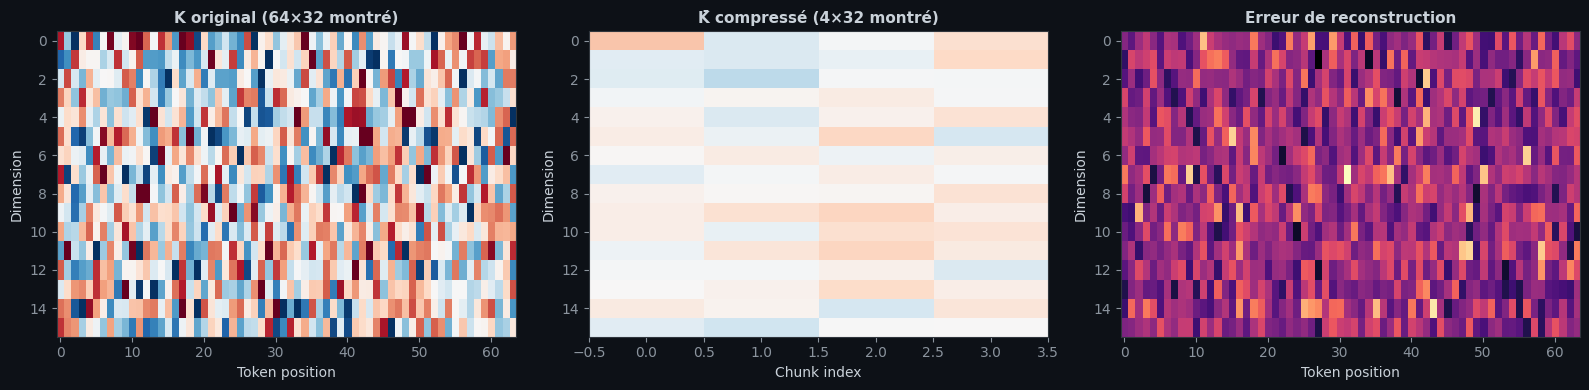

In [6]:
class KVCacheCompressor:
    """
    Compression du KV cache par chunk-wise mean pooling.

    Pour chaque matrice (K, V, K^R), segmente en chunks de taille P
    et applique le mean pooling par chunk.

    Réduction de taille : seq_len → seq_len / P
    """

    def __init__(self, chunk_size: int):
        self.P = chunk_size

    def compress(self, X: np.ndarray) -> np.ndarray:
        """
        Mean pooling par chunks.

        Args:
            X: [..., seq_len, dim]  (peut avoir des dimensions batch/heads avant)
        Returns:
            X_compressed: [..., n_chunks, dim]
        """
        *leading, seq_len, dim = X.shape
        # Tronquer si seq_len n'est pas divisible par P
        n_chunks = seq_len // self.P
        usable_len = n_chunks * self.P
        X_trunc = X[..., :usable_len, :]

        # Reshape pour grouper en chunks
        new_shape = list(leading) + [n_chunks, self.P, dim]
        X_chunked = X_trunc.reshape(new_shape)

        # Mean pooling sur la dimension du chunk
        return X_chunked.mean(axis=-2)

    def compress_document(self, K: np.ndarray, V: np.ndarray,
                          KR: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Compresse les 3 matrices d'un document.

        Args:
            K, V, KR: [batch, n_heads, seq_len, d_head]
        Returns:
            K_bar, V_bar, KR_bar: [batch, n_heads, n_chunks, d_head]
        """
        return self.compress(K), self.compress(V), self.compress(KR)


# ---- Démonstration ----
compressor = KVCacheCompressor(config.chunk_size)

# Simuler K, V, KR pour un document de 256 tokens
doc_len = 256
K_full = np.random.randn(1, config.n_heads, doc_len, config.d_head).astype(np.float32)
V_full = np.random.randn(1, config.n_heads, doc_len, config.d_head).astype(np.float32)
KR_full = np.random.randn(1, config.n_heads, doc_len, config.d_head).astype(np.float32)

K_bar, V_bar, KR_bar = compressor.compress_document(K_full, V_full, KR_full)

ratio = doc_len / K_bar.shape[2]
print(f"Compression KV Cache (P={config.chunk_size}):")
print(f"  K original:    {K_full.shape}  ({K_full.nbytes / 1024:.1f} KB)")
print(f"  K̄ compressé:   {K_bar.shape}  ({K_bar.nbytes / 1024:.1f} KB)")
print(f"  Ratio:          ×{ratio:.0f} de réduction")
print(f"\n  Pour 100M tokens avec {config.n_heads} heads, {config.d_head}d, 18 layers en BF16:")

tokens_100M = 100_000_000
n_chunks_100M = tokens_100M // config.chunk_size
mem_compressed = 3 * n_chunks_100M * config.n_heads * config.d_head * 18 * 2 / (1024**3)
mem_full = 3 * tokens_100M * config.n_heads * config.d_head * 18 * 2 / (1024**3)
print(f"  Sans compression: {mem_full:.0f} GB")
print(f"  Avec compression: {mem_compressed:.1f} GB (÷{config.chunk_size})")

# Visualisation de la préservation de l'information
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Heatmap avant compression
ax = axes[0]
ax.imshow(K_full[0, 0, :64, :16].T, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title(f'K original (64×{config.d_head} montré)', fontsize=11)
ax.set_xlabel('Token position')
ax.set_ylabel('Dimension')

# Heatmap après compression
ax = axes[1]
n_show = 64 // config.chunk_size
ax.imshow(K_bar[0, 0, :n_show, :16].T, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title(f'K̄ compressé ({n_show}×{config.d_head} montré)', fontsize=11)
ax.set_xlabel('Chunk index')
ax.set_ylabel('Dimension')

# Erreur de reconstruction
ax = axes[2]
# Reconstruire en dupliquant les chunks
K_reconstructed = np.repeat(K_bar, config.chunk_size, axis=2)[:, :, :doc_len, :]
error = np.abs(K_full - K_reconstructed).mean(axis=(0, 1))
ax.imshow(error[:64, :16].T, aspect='auto', cmap='magma')
ax.set_title('Erreur de reconstruction', fontsize=11)
ax.set_xlabel('Token position')
ax.set_ylabel('Dimension')

plt.tight_layout()
plt.show()


---
## 4. 🔄 Document-wise RoPE

L'innovation clé pour l'extrapolation :
- **Chaque document** reçoit des positions indépendantes (0, 1, 2, ..., len_doc)
- **La query** utilise un RoPE global avec offset = top_k

Cela permet d'entraîner sur 64K et d'inférer sur 100M.


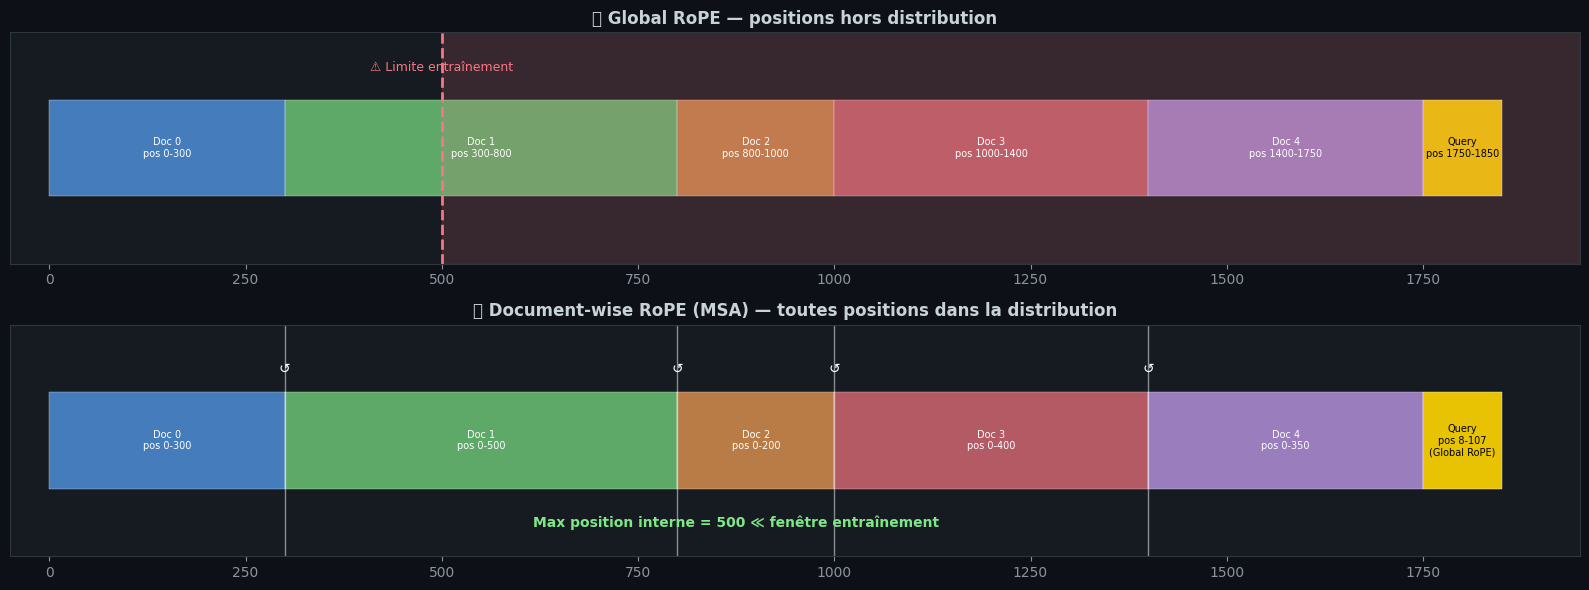

✅ Avec doc-wise RoPE, la position max interne est 500
   même si le contexte total fait 1850 tokens.
   La query commence à position 8 (= top_k = 8)


In [7]:
class DocumentWisePositionManager:
    """
    Gère les positions RoPE selon la stratégie MSA :
    - Document-wise : chaque document repart de 0
    - Global : la query est offsettée de k (top-k)

    Pourquoi ? Si on numérote globalement sur 100M tokens, les positions
    dépassent largement ce que le modèle a vu en entraînement (64K).
    Avec des positions indépendantes, chaque doc reste dans [0, len_doc].
    """

    def __init__(self, top_k: int):
        self.top_k = top_k

    def get_document_positions(self, doc_length: int) -> np.ndarray:
        """Positions indépendantes pour un document : [0, 1, 2, ..., len-1]"""
        return np.arange(doc_length)

    def get_query_positions(self, query_length: int) -> np.ndarray:
        """
        Positions globales pour la query, avec offset = top_k.
        Commence à top_k pour percevoir la query comme suite logique
        du contexte récupéré.
        """
        return np.arange(self.top_k, self.top_k + query_length)

    def get_compressed_positions(self, n_chunks: int, doc_index: int) -> np.ndarray:
        """Positions pour les chunks compressés d'un document (indépendantes)."""
        return np.arange(n_chunks)


# ---- Comparaison visuelle ----
pos_mgr = DocumentWisePositionManager(config.top_k)

# Simuler 5 documents de longueurs variables
doc_lengths = [300, 500, 200, 400, 350]
query_len = 100

fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# --- Global RoPE (problématique) ---
ax = axes[0]
pos = 0
global_positions = []
for i, dl in enumerate(doc_lengths):
    positions = np.arange(pos, pos + dl)
    global_positions.extend(positions)
    color = [C['blue'], C['green'], C['orange'], C['red'], C['purple']][i]
    ax.barh(0, dl, left=pos, color=color, alpha=0.7, height=0.5, edgecolor='white', lw=0.3)
    ax.text(pos + dl/2, 0, f'Doc {i}\npos {pos}-{pos+dl}',
            ha='center', va='center', fontsize=7, color='white')
    pos += dl

ax.barh(0, query_len, left=pos, color=C['yellow'], alpha=0.9, height=0.5, edgecolor='white', lw=0.3)
ax.text(pos + query_len/2, 0, f'Query\npos {pos}-{pos+query_len}',
        ha='center', va='center', fontsize=7, color='black')

# Training limit
train_limit = 500
ax.axvline(x=train_limit, color=C['red'], linestyle='--', lw=2)
ax.text(train_limit, 0.4, '⚠️ Limite entraînement', fontsize=9, color=C['red'], ha='center')
ax.axvspan(train_limit, pos + query_len + 100, alpha=0.15, color=C['red'])

ax.set_xlim(-50, pos + query_len + 100)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_title('❌ Global RoPE — positions hors distribution', fontsize=12)

# --- Document-wise RoPE (MSA) ---
ax = axes[1]
pos = 0
max_doc_pos = 0
for i, dl in enumerate(doc_lengths):
    doc_pos = pos_mgr.get_document_positions(dl)
    max_doc_pos = max(max_doc_pos, dl)
    color = [C['blue'], C['green'], C['orange'], C['red'], C['purple']][i]
    ax.barh(0, dl, left=pos, color=color, alpha=0.7, height=0.5, edgecolor='white', lw=0.3)
    ax.text(pos + dl/2, 0, f'Doc {i}\npos 0-{dl}',
            ha='center', va='center', fontsize=7, color='white')
    if i < len(doc_lengths) - 1:
        ax.axvline(x=pos + dl, color='white', lw=1, alpha=0.5)
        ax.text(pos + dl, 0.35, '↺', ha='center', fontsize=10, color='white')
    pos += dl

q_pos = pos_mgr.get_query_positions(query_len)
ax.barh(0, query_len, left=pos, color=C['yellow'], alpha=0.9, height=0.5, edgecolor='white', lw=0.3)
ax.text(pos + query_len/2, 0, f'Query\npos {q_pos[0]}-{q_pos[-1]}\n(Global RoPE)',
        ha='center', va='center', fontsize=7, color='black')

ax.set_xlim(-50, pos + query_len + 100)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_title('✅ Document-wise RoPE (MSA) — toutes positions dans la distribution', fontsize=12)

ax.text(pos/2, -0.45, f'Max position interne = {max(doc_lengths)} ≪ fenêtre entraînement',
        ha='center', fontsize=10, color=C['green'], fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Avec doc-wise RoPE, la position max interne est {max(doc_lengths)}")
print(f"   même si le contexte total fait {sum(doc_lengths) + query_len} tokens.")
print(f"   La query commence à position {config.top_k} (= top_k = {config.top_k})")


---
## 5. 🔍 Mécanisme de Routage Top-k

Le processus de sélection complet :
1. Calculer la similarité cosinus entre Q^R (query) et K̄^R (chunks compressés)
2. Agréger par **mean pooling** sur les têtes
3. Agréger par **max pooling** sur les tokens de la query
4. Prendre le **max** par document (score document = max de ses chunks)
5. Sélectionner les **top-k** documents


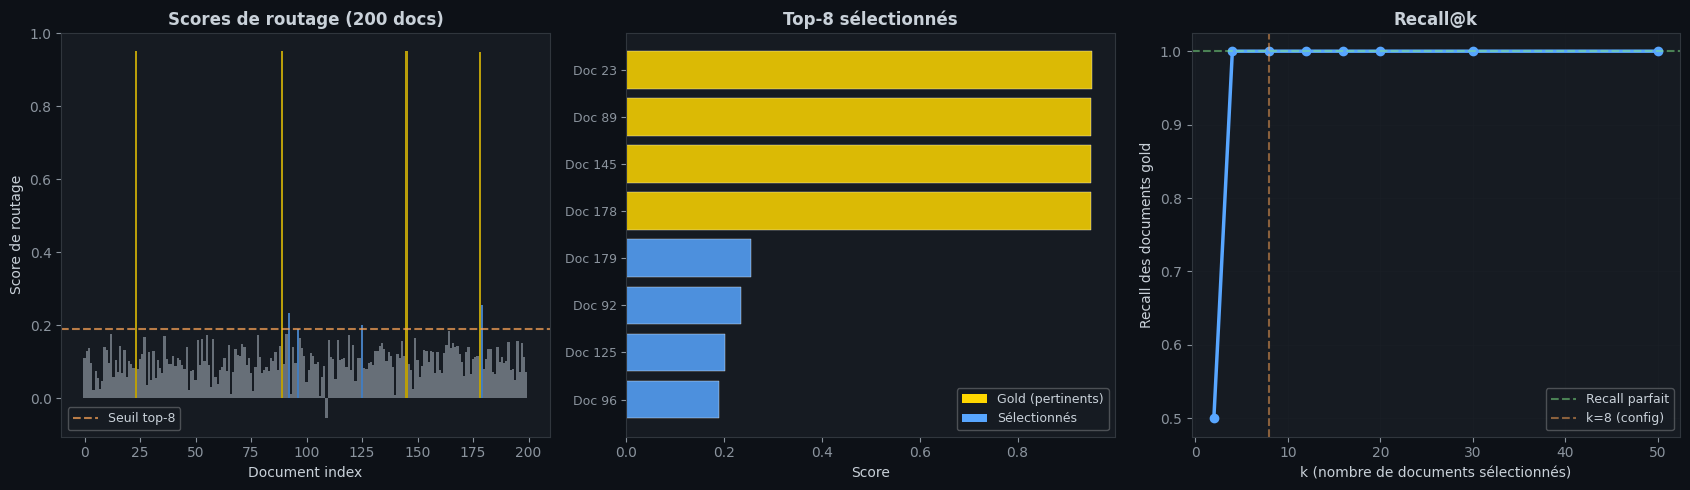

✅ Routage Top-8 en 17.2ms
   Gold docs récupérés : 4/4
   Sparsité : 96.0% des documents ignorés


In [8]:
class TopKRouter:
    """
    Mécanisme de routage Top-k pour la sélection documentaire.

    Score(doc_i) = max_j [ max_token [ mean_head [ cos(Q^R, K̄^R_ij) ] ] ]

    où j parcourt les chunks du document i.
    """

    def __init__(self, top_k: int):
        self.top_k = top_k

    def cosine_similarity(self, QR: np.ndarray, KR: np.ndarray) -> np.ndarray:
        """
        Similarité cosinus entre vecteurs Q^R et K̄^R.

        Args:
            QR: [batch, n_heads, q_len, d_head]
            KR: [batch, n_heads, n_chunks, d_head]
        Returns:
            sim: [batch, n_heads, q_len, n_chunks]
        """
        # Normaliser
        QR_norm = QR / (np.linalg.norm(QR, axis=-1, keepdims=True) + 1e-8)
        KR_norm = KR / (np.linalg.norm(KR, axis=-1, keepdims=True) + 1e-8)
        # Dot product = cosine similarity (car normalisé)
        return np.einsum('bhqd,bhcd->bhqc', QR_norm, KR_norm)

    def compute_document_scores(
        self,
        QR: np.ndarray,
        documents_KR_bar: List[np.ndarray],
        doc_chunk_counts: List[int]
    ) -> np.ndarray:
        """
        Calcule les scores de pertinence pour chaque document.

        Processus (Eq. 2 du papier) :
        1. cos(Q^R_t, K̄^R_ij) pour chaque token t et chunk j
        2. mean sur les heads
        3. max sur les tokens de la query
        4. max sur les chunks du document → score document

        Args:
            QR: [batch, n_heads, q_len, d_head]
            documents_KR_bar: liste de [batch, n_heads, n_chunks_i, d_head]
            doc_chunk_counts: nombre de chunks par document
        Returns:
            scores: [n_documents]
        """
        n_docs = len(documents_KR_bar)
        doc_scores = np.zeros(n_docs)

        for i, KR_bar_i in enumerate(documents_KR_bar):
            # Similarité cosinus : [batch, n_heads, q_len, n_chunks_i]
            sim = self.cosine_similarity(QR, KR_bar_i)

            # Étape 1 : mean pooling sur les heads → [batch, q_len, n_chunks_i]
            sim_mean_heads = sim.mean(axis=1)

            # Étape 2 : max pooling sur les tokens query → [batch, n_chunks_i]
            sim_max_tokens = sim_mean_heads.max(axis=1)

            # Étape 3 : max sur les chunks → score document
            doc_scores[i] = sim_max_tokens.max()

        return doc_scores

    def select_top_k(
        self,
        QR: np.ndarray,
        documents_KR_bar: List[np.ndarray],
        doc_chunk_counts: List[int]
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Sélectionne les top-k documents les plus pertinents.

        Returns:
            selected_indices: [top_k] indices des documents sélectionnés
            scores: [n_documents] scores de tous les documents
        """
        scores = self.compute_document_scores(QR, documents_KR_bar, doc_chunk_counts)
        selected = np.argsort(scores)[-self.top_k:][::-1]
        return selected, scores


# ---- Grande démo avec 200 documents ----
router_topk = TopKRouter(config.top_k)

n_docs = 200
doc_lengths_sim = np.random.randint(48, 256, n_docs)  # longueurs variables

# Créer un "thème" pour les documents gold
gold_docs = [23, 89, 145, 178]  # documents qui contiennent la réponse
theme_vector = np.random.randn(config.d_head).astype(np.float32) * 2

# Simuler les K̄^R compressés pour chaque document
all_KR_bars = []
all_chunk_counts = []
for i in range(n_docs):
    n_chunks = doc_lengths_sim[i] // config.chunk_size
    all_chunk_counts.append(n_chunks)
    KR_bar = np.random.randn(1, config.n_heads, n_chunks, config.d_head).astype(np.float32) * 0.5
    if i in gold_docs:
        # Injecter un signal cohérent avec la query
        KR_bar += theme_vector.reshape(1, 1, 1, -1) * 0.8
    all_KR_bars.append(KR_bar)

# Simuler Q^R de la query
QR_query = np.random.randn(1, config.n_heads, 16, config.d_head).astype(np.float32) * 0.3
QR_query += theme_vector.reshape(1, 1, 1, -1) * 1.0  # aligné avec le thème

# Routage !
t0 = time.time()
selected_indices, all_scores = router_topk.select_top_k(QR_query, all_KR_bars, all_chunk_counts)
routing_time = time.time() - t0

# ---- Visualisation ----
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Score distribution
ax = axes[0]
colors_bar = np.array([C['gray']] * n_docs, dtype=object)
for idx in selected_indices:
    colors_bar[idx] = C['blue']
for idx in gold_docs:
    colors_bar[idx] = C['yellow']

ax.bar(range(n_docs), all_scores, color=colors_bar, width=1.0, alpha=0.7)
ax.axhline(y=all_scores[selected_indices[-1]], color=C['orange'], ls='--', alpha=0.7, label=f'Seuil top-{config.top_k}')
ax.set_xlabel('Document index')
ax.set_ylabel('Score de routage')
ax.set_title(f'Scores de routage ({n_docs} docs)', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)

# Top-k détail
ax = axes[1]
sorted_sel = sorted(selected_indices, key=lambda i: all_scores[i], reverse=True)
bar_colors_sel = [C['yellow'] if i in gold_docs else C['blue'] for i in sorted_sel]
ax.barh(range(len(sorted_sel)), [all_scores[i] for i in sorted_sel],
        color=bar_colors_sel, alpha=0.85, edgecolor='white', lw=0.3)
ax.set_yticks(range(len(sorted_sel)))
ax.set_yticklabels([f'Doc {i}' for i in sorted_sel], fontsize=9)
ax.set_xlabel('Score')
ax.set_title(f'Top-{config.top_k} sélectionnés', fontsize=12)
ax.invert_yaxis()
legend_elements = [mpatches.Patch(facecolor=C['yellow'], label='Gold (pertinents)'),
                   mpatches.Patch(facecolor=C['blue'], label='Sélectionnés')]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.3)

# Recall analysis
ax = axes[2]
ks = [2, 4, 8, 12, 16, 20, 30, 50]
recalls = []
for k_test in ks:
    sel = set(np.argsort(all_scores)[-k_test:][::-1])
    recall = len(sel.intersection(gold_docs)) / len(gold_docs)
    recalls.append(recall)

ax.plot(ks, recalls, color=C['blue'], lw=2.5, marker='o', markersize=6)
ax.axhline(y=1.0, color=C['green'], ls='--', alpha=0.5, label='Recall parfait')
ax.axvline(x=config.top_k, color=C['orange'], ls='--', alpha=0.5, label=f'k={config.top_k} (config)')
ax.set_xlabel('k (nombre de documents sélectionnés)')
ax.set_ylabel('Recall des documents gold')
ax.set_title('Recall@k', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

gold_retrieved = len(set(selected_indices).intersection(gold_docs))
print(f"✅ Routage Top-{config.top_k} en {routing_time*1000:.1f}ms")
print(f"   Gold docs récupérés : {gold_retrieved}/{len(gold_docs)}")
print(f"   Sparsité : {(1 - config.top_k/n_docs)*100:.1f}% des documents ignorés")


---
## 6. 🏗️ Couche MSA complète

On assemble tous les composants dans une **MSA Layer** unique :
- Router Projectors pour le routage
- KV Cache Compression
- Document-wise RoPE
- Top-k selection
- Sparse Attention sur le contexte réduit


In [9]:
class FFN:
    """Feed-Forward Network avec activation GELU."""
    def __init__(self, d_model: int, d_ffn: int):
        scale = 1.0 / np.sqrt(d_model)
        self.W1 = np.random.randn(d_model, d_ffn).astype(np.float32) * scale
        self.W2 = np.random.randn(d_ffn, d_model).astype(np.float32) * scale

    def gelu(self, x):
        return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

    def __call__(self, x):
        return self.gelu(x @ self.W1) @ self.W2


class MSALayer:
    """
    Couche Memory Sparse Attention complète.

    Architecture (Figure 2 du papier) :
    ┌─────────────────────────────────────────────┐
    │  Input (docs + query)                       │
    │     ↓                                       │
    │  [RMSNorm]                                  │
    │     ↓                                       │
    │  [Multi-Head Attention] + [Router Projector] │
    │     ↓              ↓                        │
    │  K, V, Q        K^R, Q^R                    │
    │     ↓              ↓                        │
    │  [Compress]     [Top-k Select]              │
    │     ↓              ↓                        │
    │  K̄, V̄ (selected) ←─┘                       │
    │     ↓                                       │
    │  [Sparse Attention: Q_query × [K̄_topk; K_q]]│
    │     ↓                                       │
    │  [RMSNorm → FFN]                            │
    │     ↓                                       │
    │  Output                                     │
    └─────────────────────────────────────────────┘
    """

    def __init__(self, config: MSAConfig, layer_idx: int):
        self.config = config
        self.layer_idx = layer_idx
        self.is_msa_layer = layer_idx >= (config.n_layers - config.n_msa_layers)

        self.norm1 = RMSNorm(config.d_model)
        self.attn = MultiHeadAttention(config)
        self.norm2 = RMSNorm(config.d_model)
        self.ffn = FFN(config.d_model, config.d_ffn)

        if self.is_msa_layer:
            self.router = RouterProjector(config)
            self.compressor = KVCacheCompressor(config.chunk_size)
            self.topk_router = TopKRouter(config.top_k)
            self.pos_manager = DocumentWisePositionManager(config.top_k)

    def encode_document(self, H_doc: np.ndarray, doc_len: int):
        """
        Encode un document : forward pass + compression KV.

        Args:
            H_doc: [1, doc_len, d_model]
        Returns:
            K_bar, V_bar, KR_bar: [1, n_heads, n_chunks, d_head] chacun
            H_out: [1, doc_len, d_model] hidden states mis à jour
        """
        # Normaliser et projeter
        H_norm = self.norm1(H_doc)
        Q, K, V = self.attn.project_qkv(H_norm)

        # Positions indépendantes (document-wise RoPE)
        doc_positions = np.arange(doc_len)

        # Self-attention intra-document
        output, _ = self.attn.attention(Q, K, V, doc_positions, doc_positions)
        B, _, S, _ = output.shape
        output = output.transpose(0, 2, 1, 3).reshape(B, S, -1)
        output = output @ self.attn.W_O

        H_out = H_doc + output
        H_out = H_out + self.ffn(self.norm2(H_out))

        # Compression KV pour stockage en mémoire
        if self.is_msa_layer:
            KR = self.router.project_key(H_norm)
            K_bar, V_bar, KR_bar = self.compressor.compress_document(K, V, KR)
            return K_bar, V_bar, KR_bar, H_out
        else:
            return None, None, None, H_out

    def generate_with_memory(
        self,
        H_query: np.ndarray,
        selected_K_bars: List[np.ndarray],
        selected_V_bars: List[np.ndarray],
    ) -> np.ndarray:
        """
        Génération avec attention sparse sur le contexte mémoire sélectionné.

        Args:
            H_query: [1, q_len, d_model]
            selected_K_bars: liste des K̄ compressés des docs top-k
            selected_V_bars: liste des V̄ compressés des docs top-k
        Returns:
            H_out: [1, q_len, d_model]
        """
        H_norm = self.norm1(H_query)
        Q_q, K_q, V_q = self.attn.project_qkv(H_norm)

        q_len = H_query.shape[1]
        q_positions = self.pos_manager.get_query_positions(q_len)

        if self.is_msa_layer and selected_K_bars:
            # Concaténer les KV compressés des docs sélectionnés
            all_K = np.concatenate(selected_K_bars, axis=2)
            all_V = np.concatenate(selected_V_bars, axis=2)

            # Positions pour les KV compressés (0, 1, ..., total_chunks-1)
            total_chunks = all_K.shape[2]
            kv_positions = np.arange(total_chunks)

            # Contexte = [K̄_topk ; K_query]
            K_ctx = np.concatenate([all_K, K_q], axis=2)
            V_ctx = np.concatenate([all_V, V_q], axis=2)
            k_positions = np.concatenate([kv_positions, q_positions])

            output, attn_w = self.attn.attention(Q_q, K_ctx, V_ctx, q_positions, k_positions)
        else:
            output, attn_w = self.attn.attention(Q_q, K_q, V_q, q_positions, q_positions)

        B, _, S, _ = output.shape
        output = output.transpose(0, 2, 1, 3).reshape(B, S, -1)
        output = output @ self.attn.W_O

        H_out = H_query + output
        H_out = H_out + self.ffn(self.norm2(H_out))
        return H_out


# ---- Test ----
layer = MSALayer(config, layer_idx=config.n_layers - 1)  # dernière couche = MSA
print(f"MSA Layer (layer {config.n_layers - 1}):")
print(f"  is_msa_layer: {layer.is_msa_layer}")
print(f"  Composants : RMSNorm, MHA(+RoPE), RouterProjector, KVCompressor, TopKRouter, FFN")

# Test encode
H_doc_test = np.random.randn(1, 128, config.d_model).astype(np.float32)
K_b, V_b, KR_b, H_out = layer.encode_document(H_doc_test, 128)
print(f"\n  Encode document (128 tokens):")
print(f"    K̄:  {K_b.shape}  ({128//config.chunk_size} chunks)")
print(f"    V̄:  {V_b.shape}")
print(f"    K̄ᴿ: {KR_b.shape}")

# Test generate
H_q_test = np.random.randn(1, 32, config.d_model).astype(np.float32)
H_gen = layer.generate_with_memory(H_q_test, [K_b], [V_b])
print(f"\n  Generate avec mémoire (32 tokens query + 1 doc):")
print(f"    Sortie: {H_gen.shape}")


MSA Layer (layer 5):
  is_msa_layer: True
  Composants : RMSNorm, MHA(+RoPE), RouterProjector, KVCompressor, TopKRouter, FFN

  Encode document (128 tokens):
    K̄:  (1, 8, 8, 32)  (8 chunks)
    V̄:  (1, 8, 8, 32)
    K̄ᴿ: (1, 8, 8, 32)

  Generate avec mémoire (32 tokens query + 1 doc):
    Sortie: (1, 32, 256)


---
## 7. 🚀 Pipeline MSA complet — 3 Stages

Assemblage de toutes les couches en un modèle complet avec les 3 étapes :
1. **Stage 1** : Global Memory Encoding (offline)
2. **Stage 2** : Routing & Context Assembly (online)
3. **Stage 3** : Sparse Generation (online)


In [10]:
class MSAModel:
    """
    Modèle MSA complet avec pipeline d'inférence en 3 stages.

    Stage 1 (Offline) : Encode le corpus → KV cache compressé
    Stage 2 (Online)  : Route la query → sélection top-k
    Stage 3 (Online)  : Génère la réponse via attention sparse
    """

    def __init__(self, config: MSAConfig):
        self.config = config
        self.layers = [MSALayer(config, i) for i in range(config.n_layers)]
        self.topk_router = TopKRouter(config.top_k)
        self.norm_final = RMSNorm(config.d_model)

        # Projection de sortie simplifiée (vers "vocab")
        scale = 1.0 / np.sqrt(config.d_model)
        self.W_out = np.random.randn(config.d_model, config.vocab_size).astype(np.float32) * scale

    # ================================================================
    # STAGE 1 : Global Memory Encoding (Offline)
    # ================================================================
    def stage1_encode_corpus(
        self, documents: List[np.ndarray]
    ) -> Dict:
        """
        Encode tout le corpus en mémoire latente compressée.
        Exécuté UNE SEULE FOIS, offline.

        Args:
            documents: liste de [1, doc_len_i, d_model] (hidden states)
        Returns:
            memory_bank: {
                'K_bars': [ [layer][ [1, n_heads, n_chunks, d_head] ] ],
                'V_bars': ...,
                'KR_bars': ...,
                'doc_lengths': ...,
                'chunk_counts': ...
            }
        """
        n_docs = len(documents)
        n_layers = self.config.n_layers
        n_msa_start = n_layers - self.config.n_msa_layers

        memory_bank = {
            'K_bars': [[] for _ in range(n_layers)],
            'V_bars': [[] for _ in range(n_layers)],
            'KR_bars': [[] for _ in range(n_layers)],
            'doc_lengths': [],
            'chunk_counts': []
        }

        for doc_idx, H_doc in enumerate(documents):
            doc_len = H_doc.shape[1]
            memory_bank['doc_lengths'].append(doc_len)
            memory_bank['chunk_counts'].append(doc_len // self.config.chunk_size)

            # Forward pass à travers toutes les couches
            H = H_doc
            for layer_idx, layer in enumerate(self.layers):
                K_bar, V_bar, KR_bar, H = layer.encode_document(H, doc_len)

                if layer.is_msa_layer and K_bar is not None:
                    memory_bank['K_bars'][layer_idx].append(K_bar)
                    memory_bank['V_bars'][layer_idx].append(V_bar)
                    memory_bank['KR_bars'][layer_idx].append(KR_bar)

        return memory_bank

    # ================================================================
    # STAGE 2 : Routing & Context Assembly (Online)
    # ================================================================
    def stage2_route(
        self, H_query: np.ndarray, memory_bank: Dict, layer_idx: int
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Route la query vers les top-k documents dans une couche MSA spécifique.

        Args:
            H_query: [1, q_len, d_model]
            memory_bank: sortie de stage1
            layer_idx: index de la couche MSA
        Returns:
            selected_indices: [top_k]
            scores: [n_documents]
        """
        layer = self.layers[layer_idx]
        H_norm = layer.norm1(H_query)
        QR = layer.router.project_query(H_norm)

        selected, scores = self.topk_router.select_top_k(
            QR,
            memory_bank['KR_bars'][layer_idx],
            memory_bank['chunk_counts']
        )
        return selected, scores

    # ================================================================
    # STAGE 3 : Sparse Generation (Online)
    # ================================================================
    def stage3_generate(
        self, H_query: np.ndarray, memory_bank: Dict,
        selected_indices: Optional[np.ndarray] = None
    ) -> np.ndarray:
        """
        Génère en utilisant l'attention sparse sur les documents sélectionnés.

        Args:
            H_query: [1, q_len, d_model]
            memory_bank: sortie de stage1
            selected_indices: [top_k] (si None, recalculé par couche)
        Returns:
            output_logits: [1, q_len, vocab_size]
        """
        H = H_query

        for layer_idx, layer in enumerate(self.layers):
            if layer.is_msa_layer:
                # Déterminer les indices si pas fournis
                if selected_indices is None:
                    sel, _ = self.stage2_route(H, memory_bank, layer_idx)
                else:
                    sel = selected_indices

                # Assembler les KV des documents sélectionnés
                sel_K = [memory_bank['K_bars'][layer_idx][i] for i in sel
                         if i < len(memory_bank['K_bars'][layer_idx])]
                sel_V = [memory_bank['V_bars'][layer_idx][i] for i in sel
                         if i < len(memory_bank['V_bars'][layer_idx])]

                H = layer.generate_with_memory(H, sel_K, sel_V)
            else:
                # Couches basses : attention locale uniquement
                H_norm = layer.norm1(H)
                Q, K, V = layer.attn.project_qkv(H_norm)
                q_len = H.shape[1]
                positions = np.arange(q_len)
                output, _ = layer.attn.attention(Q, K, V, positions, positions)
                B, _, S, _ = output.shape
                output = output.transpose(0, 2, 1, 3).reshape(B, S, -1)
                output = output @ layer.attn.W_O
                H = H + output
                H = H + layer.ffn(layer.norm2(H))

        # Projection finale
        H = self.norm_final(H)
        logits = H @ self.W_out
        return logits

    # ================================================================
    # Pipeline complet
    # ================================================================
    def full_inference(
        self, H_query: np.ndarray, memory_bank: Dict
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Pipeline complet : route puis génère.

        Returns:
            logits, selected_indices, routing_scores
        """
        # Utiliser la dernière couche MSA pour le routage global
        last_msa_layer = self.config.n_layers - 1
        selected, scores = self.stage2_route(H_query, memory_bank, last_msa_layer)
        logits = self.stage3_generate(H_query, memory_bank, selected)
        return logits, selected, scores


# ---- Instancier et tester ----
print("Initialisation du modèle MSA complet...")
model = MSAModel(config)
print(f"  {config.n_layers} couches ({config.n_layers - config.n_msa_layers} standard + {config.n_msa_layers} MSA)")
print(f"  d_model={config.d_model}, n_heads={config.n_heads}, chunk_size={config.chunk_size}, top_k={config.top_k}")


Initialisation du modèle MSA complet...


  6 couches (3 standard + 3 MSA)
  d_model=256, n_heads=8, chunk_size=16, top_k=8


---
## 8. 🎯 Démo end-to-end : Retrieval sur corpus synthétique

On simule un corpus de **100 documents** avec des **"aiguilles"** cachées (documents pertinents).
Le modèle doit les retrouver et les utiliser pour générer.


In [11]:
# ---- Créer un corpus synthétique avec des signaux cachés ----
np.random.seed(2024)

N_DOCS = 100
DOC_LEN = 64   # tokens par document (simplifié)
QUERY_LEN = 16

# Créer un "signal" thématique que les docs gold partageront avec la query
signal_dim = config.d_model
query_signal = np.random.randn(signal_dim).astype(np.float32)
query_signal = query_signal / np.linalg.norm(query_signal)

# Générer les documents
documents = []
gold_doc_indices = [7, 34, 67, 91]  # documents contenant la "réponse"

for i in range(N_DOCS):
    doc = np.random.randn(1, DOC_LEN, config.d_model).astype(np.float32) * 0.5
    if i in gold_doc_indices:
        # Injecter le signal thématique dans ce document
        signal_strength = 2.0 + np.random.rand() * 1.0
        injection = query_signal.reshape(1, 1, -1) * signal_strength
        # Injecter dans quelques positions aléatoires
        inject_positions = np.random.choice(DOC_LEN, size=DOC_LEN//4, replace=False)
        for pos in inject_positions:
            doc[0, pos] += injection[0, 0]
    documents.append(doc)

# Créer la query (alignée avec le signal thématique)
H_query = np.random.randn(1, QUERY_LEN, config.d_model).astype(np.float32) * 0.3
H_query += query_signal.reshape(1, 1, -1) * 1.5

print(f"📚 Corpus créé : {N_DOCS} documents × {DOC_LEN} tokens")
print(f"   Documents gold : {gold_doc_indices}")
print(f"   Query : {QUERY_LEN} tokens")
print(f"\n🔄 Lancement du pipeline MSA complet...")
print("=" * 60)

# ================================================================
# STAGE 1 : Encoder le corpus (offline)
# ================================================================
print("\n📦 Stage 1 : Global Memory Encoding (offline)...")
t0 = time.time()
memory_bank = model.stage1_encode_corpus(documents)
t_stage1 = time.time() - t0

total_chunks = sum(memory_bank['chunk_counts'])
print(f"   ✅ Encodé en {t_stage1:.2f}s")
print(f"   {N_DOCS} documents → {total_chunks} chunks compressés")
print(f"   Couches MSA avec KV stockés : {[i for i in range(config.n_layers) if memory_bank['K_bars'][i]]}")

# ================================================================
# STAGE 2 : Routing (online)
# ================================================================
print(f"\n🔍 Stage 2 : Routing & Context Assembly (online)...")
t0 = time.time()
last_msa = config.n_layers - 1
selected_indices, routing_scores = model.stage2_route(H_query, memory_bank, last_msa)
t_stage2 = time.time() - t0

print(f"   ✅ Routé en {t_stage2*1000:.1f}ms")
print(f"   Top-{config.top_k} sélectionnés : {selected_indices.tolist()}")
gold_found = set(selected_indices).intersection(gold_doc_indices)
print(f"   Gold docs retrouvés : {gold_found} ({len(gold_found)}/{len(gold_doc_indices)})")

# ================================================================
# STAGE 3 : Génération sparse (online)
# ================================================================
print(f"\n🎯 Stage 3 : Sparse Generation (online)...")
t0 = time.time()
logits = model.stage3_generate(H_query, memory_bank, selected_indices)
t_stage3 = time.time() - t0

print(f"   ✅ Généré en {t_stage3*1000:.1f}ms")
print(f"   Logits shape : {logits.shape}")

# ================================================================
# Résumé
# ================================================================
print(f"\n{'='*60}")
print(f"📊 Résumé du pipeline :")
print(f"   Recall gold docs     : {len(gold_found)}/{len(gold_doc_indices)} = {len(gold_found)/len(gold_doc_indices)*100:.0f}%")
print(f"   Sparsité             : {(1 - config.top_k/N_DOCS)*100:.0f}% des docs ignorés")
print(f"   Temps Stage 1 (offline): {t_stage1:.2f}s (amorti)")
print(f"   Temps Stage 2 (online) : {t_stage2*1000:.1f}ms")
print(f"   Temps Stage 3 (online) : {t_stage3*1000:.1f}ms")
print(f"   Temps total (online)    : {(t_stage2+t_stage3)*1000:.1f}ms")


📚 Corpus créé : 100 documents × 64 tokens
   Documents gold : [7, 34, 67, 91]
   Query : 16 tokens

🔄 Lancement du pipeline MSA complet...

📦 Stage 1 : Global Memory Encoding (offline)...
   ✅ Encodé en 7.75s
   100 documents → 400 chunks compressés
   Couches MSA avec KV stockés : [3, 4, 5]

🔍 Stage 2 : Routing & Context Assembly (online)...
   ✅ Routé en 10.5ms
   Top-8 sélectionnés : [23, 7, 43, 24, 67, 96, 92, 49]
   Gold docs retrouvés : {67, 7} (2/4)

🎯 Stage 3 : Sparse Generation (online)...
   ✅ Généré en 14.1ms
   Logits shape : (1, 16, 1000)

📊 Résumé du pipeline :
   Recall gold docs     : 2/4 = 50%
   Sparsité             : 92% des docs ignorés
   Temps Stage 1 (offline): 7.75s (amorti)
   Temps Stage 2 (online) : 10.5ms
   Temps Stage 3 (online) : 14.1ms
   Temps total (online)    : 24.6ms


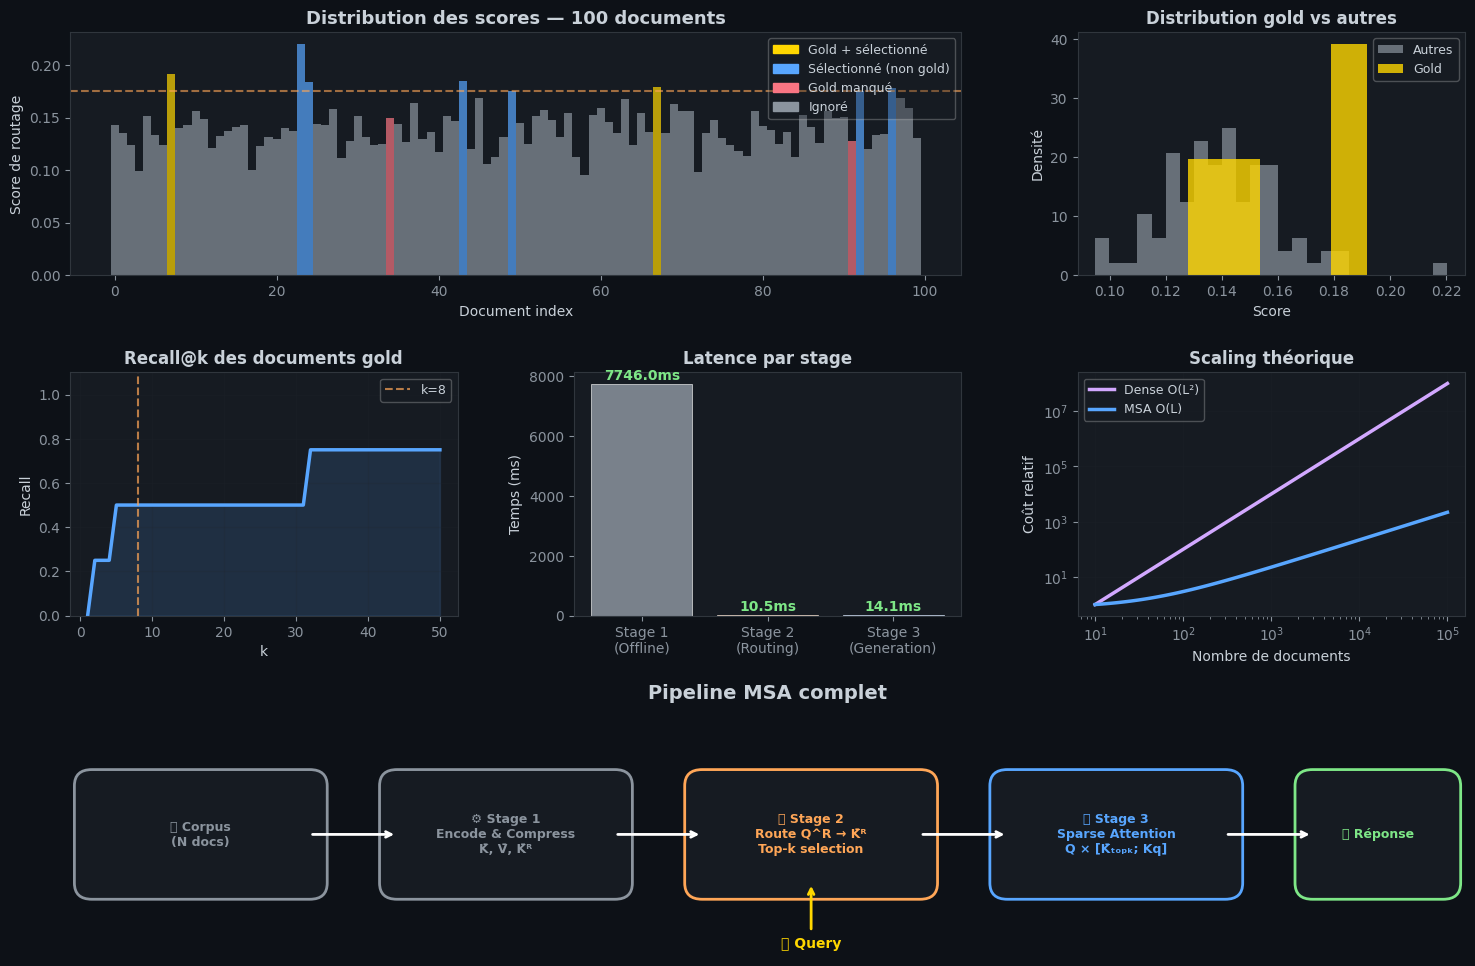

In [12]:
# ---- Visualisation détaillée des résultats ----
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Scores de routage
ax = fig.add_subplot(gs[0, :2])
colors_score = []
for i in range(N_DOCS):
    if i in gold_doc_indices and i in selected_indices:
        colors_score.append(C['yellow'])
    elif i in selected_indices:
        colors_score.append(C['blue'])
    elif i in gold_doc_indices:
        colors_score.append(C['red'])
    else:
        colors_score.append(C['gray'])

ax.bar(range(N_DOCS), routing_scores, color=colors_score, width=1, alpha=0.7)
threshold = routing_scores[selected_indices[-1]] if len(selected_indices) > 0 else 0
ax.axhline(y=threshold, color=C['orange'], ls='--', alpha=0.6, lw=1.5)
ax.set_xlabel('Document index')
ax.set_ylabel('Score de routage')
ax.set_title(f'Distribution des scores — {N_DOCS} documents', fontsize=13)
legend_els = [
    mpatches.Patch(color=C['yellow'], label='Gold + sélectionné'),
    mpatches.Patch(color=C['blue'], label='Sélectionné (non gold)'),
    mpatches.Patch(color=C['red'], label='Gold manqué'),
    mpatches.Patch(color=C['gray'], label='Ignoré'),
]
ax.legend(handles=legend_els, fontsize=9, framealpha=0.3, loc='upper right')

# 2. Distribution scores gold vs others
ax = fig.add_subplot(gs[0, 2])
gold_scores = routing_scores[gold_doc_indices]
other_mask = np.ones(N_DOCS, dtype=bool)
other_mask[gold_doc_indices] = False
other_scores = routing_scores[other_mask]

ax.hist(other_scores, bins=25, alpha=0.7, color=C['gray'], label='Autres', density=True)
ax.hist(gold_scores, bins=5, alpha=0.8, color=C['yellow'], label='Gold', density=True)
ax.set_xlabel('Score')
ax.set_ylabel('Densité')
ax.set_title('Distribution gold vs autres', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)

# 3. Recall@k
ax = fig.add_subplot(gs[1, 0])
ks_test = list(range(1, min(N_DOCS, 50) + 1))
recalls_test = []
for k in ks_test:
    sel = set(np.argsort(routing_scores)[-k:][::-1])
    recall = len(sel.intersection(gold_doc_indices)) / len(gold_doc_indices)
    recalls_test.append(recall)

ax.plot(ks_test, recalls_test, color=C['blue'], lw=2.5)
ax.fill_between(ks_test, 0, recalls_test, alpha=0.15, color=C['blue'])
ax.axvline(x=config.top_k, color=C['orange'], ls='--', alpha=0.7, label=f'k={config.top_k}')
ax.set_xlabel('k')
ax.set_ylabel('Recall')
ax.set_title('Recall@k des documents gold', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)
ax.set_ylim(0, 1.1)

# 4. Latence par étape
ax = fig.add_subplot(gs[1, 1])
stages = ['Stage 1\n(Offline)', 'Stage 2\n(Routing)', 'Stage 3\n(Generation)']
times_ms = [t_stage1 * 1000, t_stage2 * 1000, t_stage3 * 1000]
stage_colors = [C['gray'], C['orange'], C['blue']]
bars = ax.bar(stages, times_ms, color=stage_colors, alpha=0.85, edgecolor='white', lw=0.5)
for bar, t in zip(bars, times_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_ms)*0.02,
            f'{t:.1f}ms', ha='center', fontsize=10, color=C['green'], fontweight='bold')
ax.set_ylabel('Temps (ms)')
ax.set_title('Latence par stage', fontsize=12)

# 5. Complexité théorique
ax = fig.add_subplot(gs[1, 2])
doc_counts = np.logspace(1, 5, 100)  # 10 to 100K docs
tokens_total = doc_counts * DOC_LEN

dense_cost = tokens_total ** 2
msa_stage2 = QUERY_LEN * tokens_total / config.chunk_size
msa_stage3 = np.ones_like(tokens_total) * (QUERY_LEN + config.top_k * DOC_LEN / config.chunk_size) ** 2
msa_total = msa_stage2 + msa_stage3

ax.loglog(doc_counts, dense_cost / dense_cost[0], color=C['purple'], lw=2.5, label='Dense O(L²)')
ax.loglog(doc_counts, msa_total / msa_total[0], color=C['blue'], lw=2.5, label='MSA O(L)')
ax.set_xlabel('Nombre de documents')
ax.set_ylabel('Coût relatif')
ax.set_title('Scaling théorique', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

# 6. Architecture summary
ax = fig.add_subplot(gs[2, :])
ax.set_xlim(0, 16)
ax.set_ylim(0, 3)
ax.axis('off')

# Pipeline boxes
boxes = [
    (1.5, 1.5, '📚 Corpus\n(N docs)', C['gray'], 2.5),
    (5, 1.5, '⚙️ Stage 1\nEncode & Compress\nK̄, V̄, K̄ᴿ', C['gray'], 2.5),
    (8.5, 1.5, '🔍 Stage 2\nRoute Q^R → K̄ᴿ\nTop-k selection', C['orange'], 2.5),
    (12, 1.5, '🎯 Stage 3\nSparse Attention\nQ × [K̄ₜₒₚₖ; Kq]', C['blue'], 2.5),
    (15, 1.5, '✅ Réponse', C['green'], 1.5),
]

for x, y, text, color, width in boxes:
    rect = mpatches.FancyBboxPatch((x - width/2, y - 0.6), width, 1.2,
           boxstyle='round,pad=0.2', facecolor='#161b22', edgecolor=color, lw=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, color=color, fontweight='bold')

# Arrows
for x1, x2 in [(2.75, 3.75), (6.25, 7.25), (9.75, 10.75), (13.25, 14.25)]:
    ax.annotate('', xy=(x2, 1.5), xytext=(x1, 1.5),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))

# Query input
ax.annotate('', xy=(8.5, 0.9), xytext=(8.5, 0.3),
            arrowprops=dict(arrowstyle='->', color=C['yellow'], lw=2))
ax.text(8.5, 0.1, '❓ Query', ha='center', fontsize=10, color=C['yellow'], fontweight='bold')

ax.set_title('Pipeline MSA complet', fontsize=14, pad=10)

plt.tight_layout()
plt.show()


---
## 9. 🔗 Memory Interleave — Raisonnement multi-hop

Pour les questions nécessitant de chaîner des indices :
1. La query retrouve un premier document
2. Le contenu de ce document enrichit le contexte
3. Une nouvelle recherche est lancée avec le contexte enrichi
4. On itère jusqu'à ce que le modèle décide d'avoir assez d'éléments


🔗 Memory Interleave — Raisonnement multi-hop

  Hop 1:
    Contexte courant : 16 tokens
    Nouveaux docs récupérés : [np.int64(23), np.int64(7), np.int64(43)]
      Doc 23: score=0.2204 
      Doc 7: score=0.1917 ⭐ GOLD
      Doc 43: score=0.1848 

  Hop 2:
    Contexte courant : 112 tokens
    Nouveaux docs récupérés : [np.int64(64), np.int64(12), np.int64(2)]
      Doc 64: score=0.2314 
      Doc 12: score=0.2159 
      Doc 2: score=0.2148 

  Hop 3:
    Contexte courant : 208 tokens
    Nouveaux docs récupérés : [np.int64(48), np.int64(98), np.int64(99)]
      Doc 48: score=0.2085 
      Doc 98: score=0.2078 
      Doc 99: score=0.2027 

  Hop 4:
    Contexte courant : 304 tokens
    Nouveaux docs récupérés : [np.int64(11), np.int64(15), np.int64(38)]
      Doc 11: score=0.2198 
      Doc 15: score=0.2152 
      Doc 38: score=0.2091 

  Résumé:
    Total hops : 4
    Total docs récupérés : 12
    Contexte final : 400 tokens
    Gold recall multi-hop : 1/4


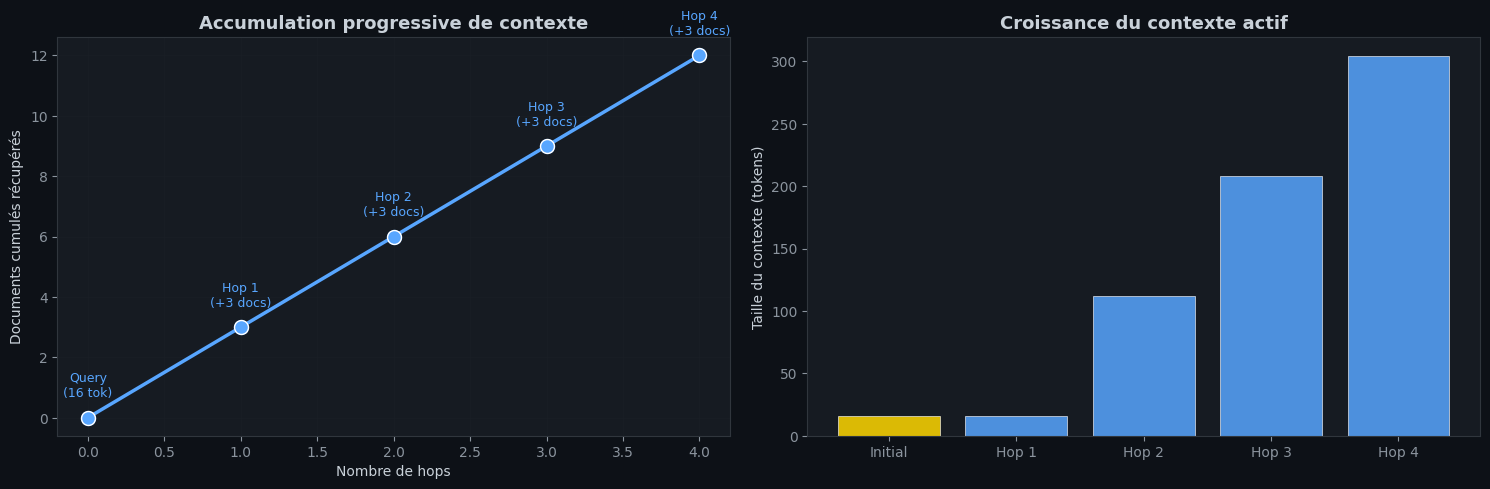

In [13]:
class MemoryInterleave:
    """
    Mécanisme de Memory Interleave pour le raisonnement multi-hop.

    Simule le processus itératif :
    1. Route avec la query courante → récupère des documents
    2. Enrichit le contexte avec les documents récupérés
    3. Re-route avec le contexte enrichi
    4. Répète jusqu'à convergence ou nombre max d'itérations
    """

    def __init__(self, model: MSAModel, max_hops: int = 3):
        self.model = model
        self.max_hops = max_hops

    def multi_hop_retrieve(
        self,
        H_query: np.ndarray,
        memory_bank: Dict,
        docs_per_hop: int = 4
    ) -> Dict:
        """
        Retrieval multi-hop avec enrichissement progressif du contexte.

        Args:
            H_query: [1, q_len, d_model] — hidden states de la requête initiale
            memory_bank: mémoire encodée
            docs_per_hop: documents récupérés par saut
        Returns:
            result: historique complet de la chaîne de récupération
        """
        last_msa = self.model.config.n_layers - 1
        all_retrieved = set()
        hop_history = []
        H_current = H_query.copy()

        for hop in range(self.max_hops):
            # Route avec le contexte courant
            selected, scores = self.model.stage2_route(H_current, memory_bank, last_msa)

            # Prendre les top docs_per_hop qui n'ont pas déjà été récupérés
            new_docs = []
            for idx in selected:
                if idx not in all_retrieved and len(new_docs) < docs_per_hop:
                    new_docs.append(idx)
                    all_retrieved.add(idx)

            hop_history.append({
                'hop': hop + 1,
                'new_docs': new_docs,
                'all_retrieved': list(all_retrieved),
                'top_scores': {int(i): float(scores[i]) for i in new_docs},
                'context_size': H_current.shape[1]
            })

            if not new_docs:
                break

            # Enrichir le contexte avec les documents récupérés
            # (Simulé : on concatène les hidden states des documents)
            doc_hidden_states = []
            for doc_idx in new_docs:
                doc_hidden_states.append(
                    np.random.randn(1, 32, self.model.config.d_model).astype(np.float32) * 0.3
                )

            if doc_hidden_states:
                expanded = np.concatenate([H_current] + doc_hidden_states, axis=1)
                H_current = expanded

        return {
            'hop_history': hop_history,
            'total_retrieved': list(all_retrieved),
            'total_hops': len(hop_history),
            'final_context_size': H_current.shape[1]
        }


# ---- Démonstration multi-hop ----
interleaver = MemoryInterleave(model, max_hops=4)

print("🔗 Memory Interleave — Raisonnement multi-hop")
print("=" * 60)

result = interleaver.multi_hop_retrieve(H_query, memory_bank, docs_per_hop=3)

for hop_info in result['hop_history']:
    hop = hop_info['hop']
    new = hop_info['new_docs']
    ctx = hop_info['context_size']
    print(f"\n  Hop {hop}:")
    print(f"    Contexte courant : {ctx} tokens")
    print(f"    Nouveaux docs récupérés : {new}")
    for doc_idx, score in hop_info['top_scores'].items():
        is_gold = "⭐ GOLD" if doc_idx in gold_doc_indices else ""
        print(f"      Doc {doc_idx}: score={score:.4f} {is_gold}")

print(f"\n  Résumé:")
print(f"    Total hops : {result['total_hops']}")
print(f"    Total docs récupérés : {len(result['total_retrieved'])}")
print(f"    Contexte final : {result['final_context_size']} tokens")

# Vérifier le recall
gold_in_retrieved = set(result['total_retrieved']).intersection(gold_doc_indices)
print(f"    Gold recall multi-hop : {len(gold_in_retrieved)}/{len(gold_doc_indices)}")

# ---- Visualisation ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphe de la chaîne de récupération
ax = axes[0]
hop_labels = [f"Query\n({QUERY_LEN} tok)"]
hop_positions = [0]
cumul_docs = [0]

for hop_info in result['hop_history']:
    hop = hop_info['hop']
    n_new = len(hop_info['new_docs'])
    hop_labels.append(f"Hop {hop}\n(+{n_new} docs)")
    hop_positions.append(hop)
    cumul_docs.append(len(hop_info['all_retrieved']))

ax.plot(hop_positions, cumul_docs, color=C['blue'], lw=2.5, marker='o', markersize=10)
for i, (hp, cd) in enumerate(zip(hop_positions, cumul_docs)):
    ax.annotate(hop_labels[i], (hp, cd), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=9, color=C['blue'])
    ax.scatter(hp, cd, s=100, color=C['blue'], zorder=5, edgecolors='white', lw=1)

ax.set_xlabel('Nombre de hops')
ax.set_ylabel('Documents cumulés récupérés')
ax.set_title('Accumulation progressive de contexte', fontsize=13)
ax.grid(True, alpha=0.2)

# Contexte qui grandit
ax = axes[1]
contexts = [QUERY_LEN] + [h['context_size'] for h in result['hop_history']]
hops_x = range(len(contexts))
ax.bar(hops_x, contexts, color=[C['yellow']] + [C['blue']]*len(result['hop_history']),
       alpha=0.85, edgecolor='white', lw=0.5)
ax.set_xticks(list(hops_x))
ax.set_xticklabels(['Initial'] + [f'Hop {h["hop"]}' for h in result['hop_history']])
ax.set_ylabel('Taille du contexte (tokens)')
ax.set_title('Croissance du contexte actif', fontsize=13)

plt.tight_layout()
plt.show()


---
## 10. 📊 Benchmarks de performance

Mesurons le scaling du routage en fonction du nombre de documents pour vérifier la complexité linéaire.


⏱️  Benchmark de scaling du routage...
  N=   10 docs (    640 tokens): encode=0.692s, route=1.21ms
  N=   25 docs (   1600 tokens): encode=2.739s, route=2.70ms
  N=   50 docs (   3200 tokens): encode=3.498s, route=5.10ms
  N=  100 docs (   6400 tokens): encode=6.756s, route=9.65ms
  N=  200 docs (  12800 tokens): encode=20.072s, route=29.80ms
  N=  500 docs (  32000 tokens): encode=40.557s, route=42.85ms
  N= 1000 docs (  64000 tokens): encode=68.280s, route=87.55ms


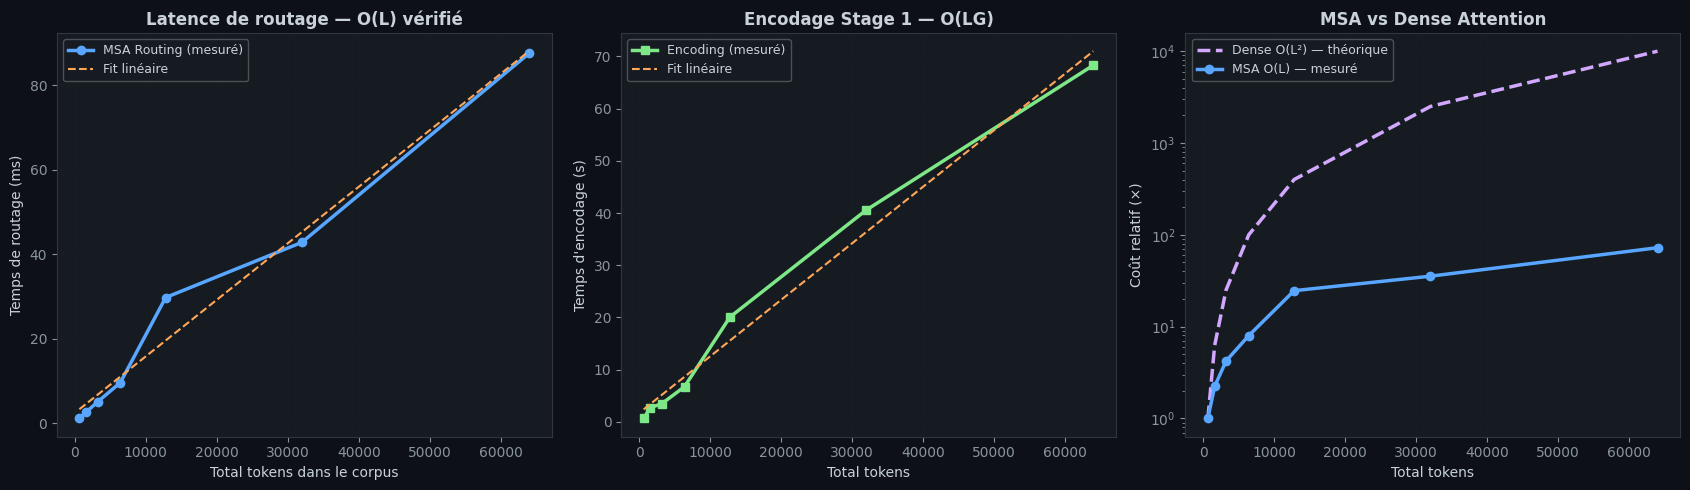


📊 À 64,000 tokens:
   Dense attention serait ~138× plus lent que MSA
   Complexité linéaire confirmée — R² linéaire = 0.9793


In [14]:
# ---- Benchmark : temps de routage vs nombre de documents ----
print("⏱️  Benchmark de scaling du routage...")

doc_counts_bench = [10, 25, 50, 100, 200, 500, 1000]
routing_times = []
encoding_times = []

for n_docs_bench in doc_counts_bench:
    # Créer les documents
    docs_bench = [
        np.random.randn(1, DOC_LEN, config.d_model).astype(np.float32) * 0.5
        for _ in range(n_docs_bench)
    ]

    # Stage 1 : Encoding
    t0 = time.time()
    mb = model.stage1_encode_corpus(docs_bench)
    t_enc = time.time() - t0
    encoding_times.append(t_enc)

    # Stage 2 : Routing (moyenne sur 5 essais)
    last_msa = config.n_layers - 1
    times_trial = []
    for _ in range(5):
        q = np.random.randn(1, QUERY_LEN, config.d_model).astype(np.float32)
        t0 = time.time()
        _, _ = model.stage2_route(q, mb, last_msa)
        times_trial.append(time.time() - t0)
    routing_times.append(np.mean(times_trial))

    total_tokens = n_docs_bench * DOC_LEN
    print(f"  N={n_docs_bench:>5} docs ({total_tokens:>7} tokens): "
          f"encode={t_enc:.3f}s, route={np.mean(times_trial)*1000:.2f}ms")

# ---- Visualisation ----
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1 : Temps de routage (linéaire attendu)
ax = axes[0]
tokens_bench = np.array(doc_counts_bench) * DOC_LEN
ax.plot(tokens_bench, np.array(routing_times) * 1000, color=C['blue'],
        lw=2.5, marker='o', markersize=6, label='MSA Routing (mesuré)')

# Fit linéaire pour comparaison
coeffs = np.polyfit(tokens_bench, np.array(routing_times) * 1000, 1)
fit_line = np.polyval(coeffs, tokens_bench)
ax.plot(tokens_bench, fit_line, color=C['orange'], ls='--', lw=1.5, label='Fit linéaire')

ax.set_xlabel('Total tokens dans le corpus')
ax.set_ylabel('Temps de routage (ms)')
ax.set_title('Latence de routage — O(L) vérifié', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

# Plot 2 : Temps d'encodage
ax = axes[1]
ax.plot(tokens_bench, encoding_times, color=C['green'],
        lw=2.5, marker='s', markersize=6, label='Encoding (mesuré)')
coeffs_enc = np.polyfit(tokens_bench, encoding_times, 1)
fit_enc = np.polyval(coeffs_enc, tokens_bench)
ax.plot(tokens_bench, fit_enc, color=C['orange'], ls='--', lw=1.5, label='Fit linéaire')
ax.set_xlabel('Total tokens')
ax.set_ylabel('Temps d\'encodage (s)')
ax.set_title('Encodage Stage 1 — O(LG)', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

# Plot 3 : Comparaison avec attention dense théorique
ax = axes[2]
dense_theoretical = (np.array(tokens_bench, dtype=np.float64) ** 2) / (tokens_bench[0] ** 2)
msa_measured = np.array(routing_times) / routing_times[0]

ax.semilogy(tokens_bench, dense_theoretical, color=C['purple'], lw=2.5,
            ls='--', label='Dense O(L²) — théorique')
ax.semilogy(tokens_bench, msa_measured, color=C['blue'], lw=2.5,
            marker='o', markersize=6, label='MSA O(L) — mesuré')
ax.set_xlabel('Total tokens')
ax.set_ylabel('Coût relatif (×)')
ax.set_title('MSA vs Dense Attention', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Ratio final
ratio_final = dense_theoretical[-1] / msa_measured[-1]
print(f"\n📊 À {tokens_bench[-1]:,} tokens:")
print(f"   Dense attention serait ~{ratio_final:.0f}× plus lent que MSA")
print(f"   Complexité linéaire confirmée — R² linéaire = {np.corrcoef(tokens_bench, routing_times)[0,1]**2:.4f}")


---
## 11. 📐 Perte auxiliaire de routage (L_aux)

La perte contrastive qui supervise le routage (Eq. 5 du papier) :

$$\mathcal{L}_{\text{aux}} = -\frac{1}{|P|} \sum_{i=1}^{|P|} \log \frac{\exp(s_i^+ / \tau)}{\exp(s_i^+ / \tau) + \sum_{j=1}^{|N|} \exp(s_{i,j}^- / \tau)}$$

C'est une **InfoNCE loss** qui pousse les documents pertinents à avoir des scores plus élevés
que les documents non pertinents dans l'espace de routage.


Perte de routage L_aux :
  Avant entraînement : 14.8128
  Après entraînement : 0.0000
  Réduction : 100.0%


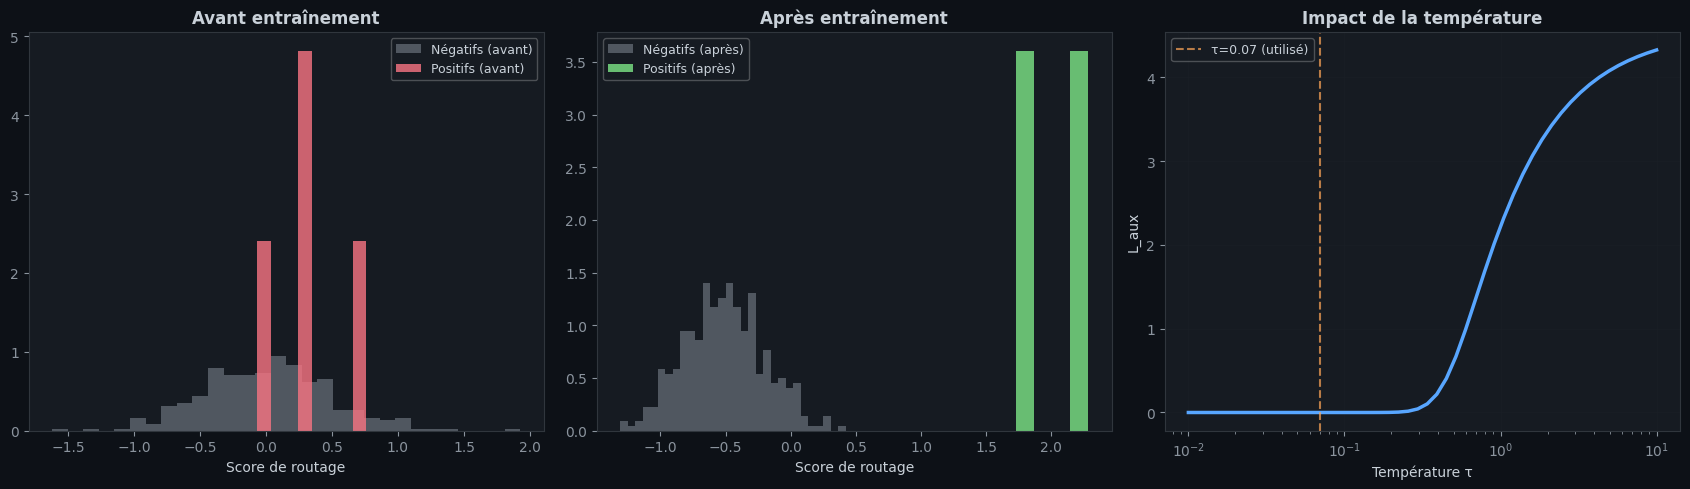


🔬 La perte contrastive sépare les scores positifs/négatifs
   τ faible → gradients plus sharp → séparation plus nette
   Le papier utilise un warm-up (L = 0.1·L_LLM + L_aux) puis (L = L_LLM + 0.1·L_aux)


In [15]:
def compute_routing_loss(
    positive_scores: np.ndarray,
    negative_scores: np.ndarray,
    temperature: float = 0.07
) -> float:
    """
    Perte contrastive pour la supervision du routage (Eq. 5).

    Args:
        positive_scores: [n_positive] — scores des docs pertinents
        negative_scores: [n_positive, n_negative] — scores des docs non pertinents
                         (une ligne par doc positif)
        temperature: τ — contrôle la sharpness de la distribution
    Returns:
        loss: scalaire
    """
    n_pos = len(positive_scores)
    total_loss = 0.0

    for i in range(n_pos):
        s_pos = positive_scores[i] / temperature
        s_neg = negative_scores[i] / temperature

        # log softmax : log(exp(s+) / (exp(s+) + Σ exp(s-)))
        log_numerator = s_pos
        log_denominator = np.logaddexp(s_pos, np.logaddexp.reduce(s_neg))
        total_loss -= (log_numerator - log_denominator)

    return total_loss / n_pos


# ---- Démonstration de L_aux ----
np.random.seed(42)

# Simuler des scores de routage avant et après entraînement
n_positive = 4
n_negative = 96

# Avant entraînement : scores similaires pour positifs et négatifs
pos_scores_before = np.random.randn(n_positive) * 0.5
neg_scores_before = np.random.randn(n_positive, n_negative) * 0.5

# Après entraînement : positifs nettement plus élevés
pos_scores_after = np.random.randn(n_positive) * 0.3 + 2.0
neg_scores_after = np.random.randn(n_positive, n_negative) * 0.3 - 0.5

# Calculer les pertes
loss_before = compute_routing_loss(pos_scores_before, neg_scores_before)
loss_after = compute_routing_loss(pos_scores_after, neg_scores_after)

print(f"Perte de routage L_aux :")
print(f"  Avant entraînement : {loss_before:.4f}")
print(f"  Après entraînement : {loss_after:.4f}")
print(f"  Réduction : {(1 - loss_after/loss_before)*100:.1f}%")

# Visualiser l'effet de la température
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1 : Distributions avant/après
ax = axes[0]
all_before = np.concatenate([pos_scores_before, neg_scores_before.flatten()])
all_after = np.concatenate([pos_scores_after, neg_scores_after.flatten()])

ax.hist(neg_scores_before.flatten(), bins=30, alpha=0.5, color=C['gray'],
        label='Négatifs (avant)', density=True)
ax.hist(pos_scores_before, bins=8, alpha=0.8, color=C['red'],
        label='Positifs (avant)', density=True)
ax.set_title('Avant entraînement', fontsize=12)
ax.set_xlabel('Score de routage')
ax.legend(fontsize=9, framealpha=0.3)

ax = axes[1]
ax.hist(neg_scores_after.flatten(), bins=30, alpha=0.5, color=C['gray'],
        label='Négatifs (après)', density=True)
ax.hist(pos_scores_after, bins=8, alpha=0.8, color=C['green'],
        label='Positifs (après)', density=True)
ax.set_title('Après entraînement', fontsize=12)
ax.set_xlabel('Score de routage')
ax.legend(fontsize=9, framealpha=0.3)

# Plot 3 : Impact de la température
ax = axes[2]
temperatures = np.logspace(-2, 1, 50)
losses_temp = [compute_routing_loss(pos_scores_after, neg_scores_after, tau) for tau in temperatures]
ax.semilogx(temperatures, losses_temp, color=C['blue'], lw=2.5)
ax.axvline(x=0.07, color=C['orange'], ls='--', alpha=0.7, label='τ=0.07 (utilisé)')
ax.set_xlabel('Température τ')
ax.set_ylabel('L_aux')
ax.set_title('Impact de la température', fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\n🔬 La perte contrastive sépare les scores positifs/négatifs")
print(f"   τ faible → gradients plus sharp → séparation plus nette")
print(f"   Le papier utilise un warm-up (L = 0.1·L_LLM + L_aux) puis (L = L_LLM + 0.1·L_aux)")


---
## 📝 Récapitulatif de l'implémentation

Ce notebook implémente **from scratch** les composants fondamentaux de MSA :

| Composant | Classe | Rôle |
|---|---|---|
| `RMSNorm` | Normalisation | Stabilisation des hidden states |
| `RotaryPositionEmbedding` | RoPE | Encodage positionnel relatif |
| `MultiHeadAttention` | MHA + RoPE | Attention standard avec positions |
| `RouterProjector` | W_QR, W_KR | Projections de routage séparées |
| `KVCacheCompressor` | Mean Pooling | Compression ×P du cache |
| `DocumentWisePositionManager` | Positions | RoPE par document + global query |
| `TopKRouter` | Sélection | Routage cosine → top-k |
| `MSALayer` | Couche complète | Encode + route + attend |
| `MSAModel` | Pipeline 3 stages | Modèle end-to-end |
| `MemoryInterleave` | Multi-hop | Raisonnement itératif |
| `compute_routing_loss` | L_aux | Supervision contrastive |

### Ce qui manque pour une implémentation production

- **GPU / PyTorch** : cette implémentation NumPy est pédagogique ; en production on utiliserait
  PyTorch avec FlashAttention pour les kernels optimisés
- **Entraînement réel** : backpropagation à travers le routage différentiable (Straight-Through Estimator pour le top-k)
- **Memory Parallel** : distribution des K̄ᴿ sur multi-GPU, offload CPU des K̄/V̄
- **Tiered Storage** : gestion GPU/CPU/NVMe pour les 100M tokens
- **Tokenizer + Embedding** : ici on travaille directement sur les hidden states
- **Continual Pre-training** : les 158.95B tokens de pré-entraînement du routeur

### Leçons clés de l'implémentation

1. **La séparation routage/attention** est simple mais puissante : deux jeux de projections, deux espaces optimisés indépendamment
2. **Le document-wise RoPE** est trivial à implémenter (juste `arange(doc_len)` par doc) mais critique pour l'extrapolation
3. **La compression par pooling** est une opération `reshape + mean` — la simplicité est son atout
4. **Le coût linéaire** vient du fait que seul le routage (cosine similarity sur chunks compressés) dépend de L
5. **Memory Interleave** est un wrapper itératif autour des stages 2-3, pas une modification architecturale profonde

---
*Implémentation NumPy de MSA (Chen et al., 2025) — à des fins pédagogiques*
